# Text Summarization

- Abstractive 모델 구성을 위한 텍스트 전처리 단계가 체계적으로 진행되었다.  
&rarr; 분석단계, 정제단계, 정규화와 불용어 제거, 데이터셋 분리, 인코딩 과정이 빠짐없이 체계적으로 진행되었다.  

- 텍스트 요약모델이 성공적으로 학습되었음을 확인하였다.  
&rarr; 모델 학습이 진행되면서 train loss와 validation loss가 감소하는 경향을 그래프를 통해 확인했으며, 실제 요약문에 있는 핵심 단어들이 요약 문장 안에 포함되었다.  

- Extractive 요약을 시도해 보고 Abstractive 요약 결과과 함께 비교해 보았다.  
&rarr; 두 요약 결과를 문법완성도 측면과 핵심단어 포함 측면으로 나누어 비교하고 분석 결과를 표로 정리하여 제시하였다.  

# 0. 라이브러리 import 및 세팅

In [ ]:
import nltk
nltk.download('stopwords')

import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from bs4 import BeautifulSoup



from collections import Counter
import pickle

import urllib.request
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='bs4')


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/minkyujeong/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [189]:
from importlib.metadata import version

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import summa
from summa.summarizer import summarize

print(nltk.__version__)
print(torch.__version__)
print(pd.__version__)
print(version('summa'))

3.7
2.7.1+cu126
1.4.4
1.2.0


In [161]:
DATA_PATH = "./summary_data/" # 데이터 관련 경로
MODEL_PATH = "./summary_models/" # 모델 관련 경로

# 1. 데이터 전처리 및 세팅

## 1.1. 데이터 불러오기

In [4]:
FILE_NAME = 'news_summary_more.csv'
URL = "https://raw.githubusercontent.com/sunnysai12345/News_Summary/master/news_summary_more.csv"

In [5]:
if not os.path.exists(DATA_PATH + FILE_NAME):
    print(f"{DATA_PATH + FILE_NAME} 파일이 없습니다. 다운로드를 시작합니다...")
    urllib.request.urlretrieve(URL, filename=DATA_PATH+FILE_NAME)
    print("다운로드 완료!")
else:
    print(f"{DATA_PATH + FILE_NAME} 파일이 이미 존재합니다. 바로 불러옵니다.")

./summary_data/news_summary_more.csv 파일이 이미 존재합니다. 바로 불러옵니다.


In [6]:
data = pd.read_csv(DATA_PATH + FILE_NAME, encoding='iso-8859-1')
print(len(data))

98401


In [7]:
data.head()

,headlines,text
0,upGrad learner switches to career in ML & Al w...,"Saurav Kant, an alumnus of upGrad and IIIT-B's..."
1,Delhi techie wins free food from Swiggy for on...,Kunal Shah's credit card bill payment platform...
2,New Zealand end Rohit Sharma-led India's 12-ma...,New Zealand defeated India by 8 wickets in the...
3,Aegon life iTerm insurance plan helps customer...,"With Aegon Life iTerm Insurance plan, customer..."
4,"Have known Hirani for yrs, what if MeToo claim...",Speaking about the sexual harassment allegatio...


## 1.2. 데이터 분석 및 전처리

### 1.2.1. 데이터 분석 (중복 샘플 및 결측치 확인)

- 중복 샘플 확인

In [8]:
print("전체 샘플 수: ", len(data))
print('text 열에서 중복을 배제한 유일한 샘플의 수 :', data['text'].nunique())
print('headlines 열에서 중복을 배제한 유일한 샘플의 수 :', data['headlines'].nunique())

전체 샘플 수:  98401
text 열에서 중복을 배제한 유일한 샘플의 수 : 98360
headlines 열에서 중복을 배제한 유일한 샘플의 수 : 98280


In [9]:
data[data.duplicated(subset=['headlines'], keep=False)].sort_values(by='headlines').head(10)

,headlines,text
64843,'Merchant of death' title inspired founding of...,After confusing his brother's death with that ...
15260,'Merchant of death' title inspired founding of...,A French newspaper in 1888 confused the death ...
67136,16-yr-old Afridi hit then-fastest ODI ton with...,Former Pakistani all-rounder Shahid Afridi sma...
45643,16-yr-old Afridi hit then-fastest ODI ton with...,"Former Pakistani all-rounder Shahid Afridi, wh..."
27674,1st Wimbledon was organised to fund repair of ...,"The first-ever Wimbledon competition, held in ..."
82399,1st Wimbledon was organised to fund repair of ...,"The first ever Wimbledon competition, held in ..."
72502,1st bowler hit for 6 sixes in 1 over was pacer...,West Indies' cricketing legend Gary Sobers bec...
19411,1st bowler hit for 6 sixes in 1 over was pacer...,Windies' cricketing legend Gary Sobers became ...
78244,1st player to hit 6 sixes in 1 over was born w...,"Former Windies' cricketer Garry Sobers, the fi..."
23938,1st player to hit 6 sixes in 1 over was born w...,"Former Windies' cricketer Garry Sobers, the fi..."


In [10]:
# 필요하면 중복 제거
# data.drop_duplicates(subset = ['text'], inplace=True)
# print('전체 샘플수 :', (len(data)))

&rarr; 위에서 확인한바, text는 중복 샘플이 없고  
중복되는 headline은 비슷한 내용의 text를 다루고 있으므로 제거하지 않는게 이롭다고 판단

- 결측치 확인

In [11]:
print(data.isnull().sum())

headlines    0
text         0
dtype: int64


In [12]:
# 결측치 있으면 제거
# data.dropna(axis=0, inplace=True)
# print('전체 샘플수 :', (len(data)))

&rarr; 결측치 없음

### 1.2.2 데이터 정제 (text normalization, 불용어 제거 등)

In [13]:
# text normalization을 위한 사전 불러오기
with open(DATA_PATH + "contractions.pickle", 'rb') as f:
    contractions = pickle.load(f)

print("text normalization 사전 수: ", len(contractions))

text normalization 사전 수:  120


In [14]:
# 불용어 제거를 위한 불용어 확인
print('불용어 개수 :', len(stopwords.words('english') ))
print(type(stopwords.words('english')))
print(stopwords.words('english')[:5])

불용어 개수 : 198
<class 'list'>
['a', 'about', 'above', 'after', 'again']


In [15]:
# headline 단어 개수 확인
head_count = []
for headline in data['headlines']:
    head_count.append(len(headline.split()))

head_count = np.array(head_count)
print(np.max(head_count))

18


&rarr; headline은 아무리 많아도 18개의 단어로 구성되어 있고, 자연스러운 번역을 위해 불용어를 제거하지 않을 것임

In [16]:
# 데이터 전처리 함수
# headline의 경우: remove_stopwords=False
def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower() # 텍스트 소문자화
    sentence = BeautifulSoup(sentence, "lxml").text # <br />, <a href = ...> 등의 html 태그 제거
    sentence = re.sub(r'\([^)]*\)', '', sentence) # 괄호로 닫힌 문자열 (...) 제거 Ex) my husband (and myself!) for => my husband for
    sentence = re.sub('"','', sentence) # 쌍따옴표 " 제거
    sentence = ' '.join([contractions[t] if t in contractions else t for t in sentence.split(" ")]) # 약어 정규화
    sentence = re.sub(r"'s\b","", sentence) # 소유격 제거. Ex) roland's -> roland
    sentence = re.sub("[^a-zA-Z]", " ", sentence) # 영어 외 문자(숫자, 특수문자 등) 공백으로 변환
    sentence = re.sub('[m]{2,}', 'mm', sentence) # m이 3개 이상이면 2개로 변경. Ex) ummmmmmm yeah -> umm yeah

    # 불용어 제거 (Text)
    if remove_stopwords:
        tokens = ' '.join(word for word in sentence.split() if not word in stopwords.words('english') if len(word) > 1)
    # 불용어 미제거 (Summary)
    else:
        tokens = ' '.join(word for word in sentence.split() if len(word) > 1)
    return tokens

In [ ]:
# # 전체 text 데이터에 대한 전처리 수행
# clean_text = []

# for sentence in data['text']:
#     clean_text.append(preprocess_sentence(sentence))

# # 전처리 후 출력
# print("text 전처리 후 결과: ", clean_text[:5])

text 전처리 후 결과:  ['saurav kant alumnus upgrad iiit pg program machine learning artificial intelligence sr systems engineer infosys almost years work experience program upgrad degree career support helped transition data scientist tech mahindra salary hike upgrad online power learning powered lakh careers', 'kunal shah credit card bill payment platform cred gave users chance win free food swiggy one year pranav kaushik delhi techie bagged reward spending cred coins users get one cred coin per rupee bill paid used avail rewards brands like ixigo bookmyshow ubereats cult fit', 'new zealand defeated india wickets fourth odi hamilton thursday win first match five match odi series india lost international match rohit sharma captaincy consecutive victories dating back march match witnessed india getting seventh lowest total odi cricket history', 'aegon life iterm insurance plan customers enjoy tax benefits premiums paid save taxes plan provides life cover age years also customers options insur

In [ ]:
# # 전체 headline 데이터에 대한 전처리 수행
# clean_hlines = []

# for sentence in data['headlines']:
#     clean_hlines.append(preprocess_sentence(sentence, remove_stopwords=False)) # 불용어 제거 안 함

# # 전처리 후 출력
# print("headlines 전처리 후 결과: ", clean_hlines[:5])

headlines 전처리 후 결과:  ['upgrad learner switches to career in ml al with salary hike', 'delhi techie wins free food from swiggy for one year on cred', 'new zealand end rohit sharma led india match winning streak', 'aegon life iterm insurance plan helps customers save tax', 'have known hirani for yrs what if metoo claims are not true sonam']


In [ ]:
# # 전처리 수행에 시간이 많이 소요되므로 재사용을 위해 전처리된 text와 headline을 저장
# with open(DATA_PATH + "clean_text.pickle", 'wb') as f:
#     pickle.dump(clean_text, f)

# with open(DATA_PATH + "clean_headlines.pickle", 'wb') as f:
#     pickle.dump(clean_hlines, f)

In [104]:
# 불러와서 사용할 때 활성화
with open(DATA_PATH + "clean_text.pickle", 'rb') as f:
    clean_text = pickle.load(f)

with open(DATA_PATH + "clean_headlines.pickle", 'rb') as f:
    clean_hlines = pickle.load(f)

data = pd.DataFrame({"text":[], "headlines":[]})

- 빈 값 생긴 샘플 있는지 확인

In [105]:
data['text'] = clean_text
data['headlines'] = clean_hlines

# 빈 값을 Null 값으로 변환
data.replace('', np.nan, inplace=True)
print(data.isnull().sum())

text         0
headlines    0
dtype: int64


In [106]:
# 빈 값 생겼으면 제거
# data.dropna(axis=0, inplace=True)
# print('전체 샘플수 :', (len(data)))

## 1.3. 데이터셋 분리

### 1.3.1. 샘플의 최대 길이 정하기

In [107]:
# 길이 분포 출력
text_len = [len(s.split()) for s in data['text']]
hlines_len = [len(s.split()) for s in data['headlines']]

print('text의 길이 최솟값: {}'.format(np.min(text_len)))
print('text의 길이 최댓값: {}'.format(np.max(text_len)))
print('text의 길이 평균값 : {}'.format(np.mean(text_len)))
print('text의 평균 중앙값: {}'.format(np.median(text_len)))
print('headlines의 길이 최솟값 : {}'.format(np.min(hlines_len)))
print('headlines의 길이 최댓값 : {}'.format(np.max(hlines_len)))
print('headlines의 길이 평균값 : {}'.format(np.mean(hlines_len)))
print('headlines의 평균 중앙값 : {}'.format(np.median(hlines_len)))

text의 길이 최솟값: 1
text의 길이 최댓값: 60
text의 길이 평균값 : 35.09983638377659
text의 평균 중앙값: 35.0
headlines의 길이 최솟값 : 1
headlines의 길이 최댓값 : 16
headlines의 길이 평균값 : 9.299651426306644
headlines의 평균 중앙값 : 9.0


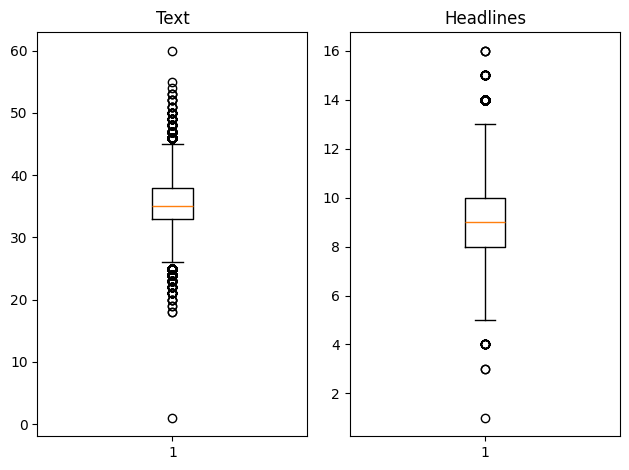

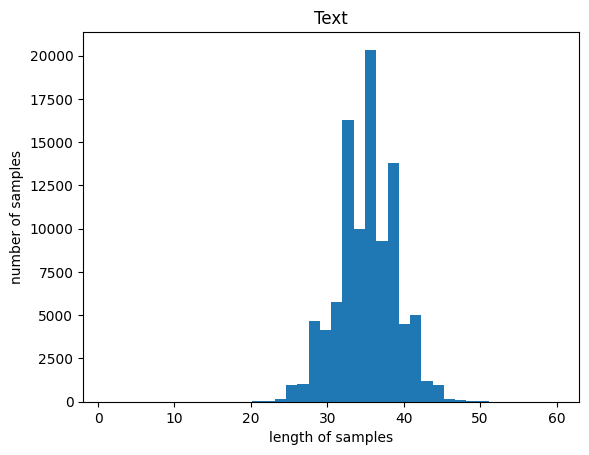

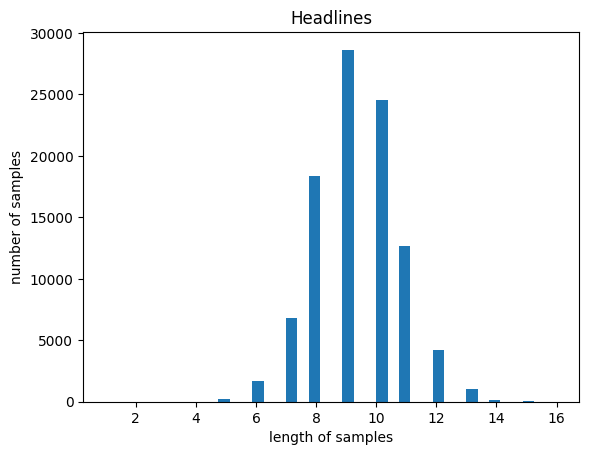

In [108]:
plt.subplot(1,2,1)
plt.boxplot(text_len)
plt.title('Text')
plt.subplot(1,2,2)
plt.boxplot(hlines_len)
plt.title('Headlines')
plt.tight_layout()
plt.show()

plt.title('Text')
plt.hist(text_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

plt.title('Headlines')
plt.hist(hlines_len, bins = 40)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

각 데이터의 평균과 중앙값이 비슷하게 위치하고, 평균을 중심으로 정규분포와 비슷하게 빈도가 줄어드는 형태임  
&rarr; 양 극단을 제외하고는 최대한 많이 사용하는 게 좋다고 판단


In [109]:
text_max_len = 42
text_min_len = 28

hline_max_len = 12
hline_min_len = 7

In [110]:
# max_len 적용 시 데이터의 몇 %가 해당하는지 계산
def below_threshold_len(max_len, min_len, nested_list):
  cnt = 0
  for s in nested_list:
    if(len(s.split()) <= max_len) and (len(s.split()) >= min_len):
        cnt = cnt + 1
  print('전체 샘플 중 길이가 %s 이하인 샘플의 비율: %s'%(max_len, (cnt / len(nested_list))))

In [111]:
below_threshold_len(text_max_len, text_min_len, data['text'])
below_threshold_len(hline_max_len, hline_min_len, data['headlines'])

전체 샘플 중 길이가 42 이하인 샘플의 비율: 0.9523785327384884
전체 샘플 중 길이가 12 이하인 샘플의 비율: 0.9683844676375241


In [112]:
# 최소 길이 이상, 최대 길이 이하인 데이터만 남기기
data = data[data['text'].apply(lambda x: text_min_len <= len(x.split()) <= text_max_len)]
print('text 길이 적용 후 전체 샘플수 :', (len(data)))
data = data[data['headlines'].apply(lambda x: hline_min_len <= len(x.split()) <= hline_max_len)]
print('headlines 길이 적용 후 전체 샘플수 :', (len(data)))

text 길이 적용 후 전체 샘플수 : 93715
headlines 길이 적용 후 전체 샘플수 : 90792


### 1.3.2. 시작 토큰과 종료 토큰 추가

In [113]:
# headlines에는 시작 토큰과 종료 토큰을 추가
data['decoder_input'] = data['headlines'].apply(lambda x : 'bostoken '+ x)
data['decoder_target'] = data['headlines'].apply(lambda x : x + ' eostoken')
data.head()

,text,headlines,decoder_input,decoder_target
0,saurav kant alumnus upgrad iiit pg program mac...,upgrad learner switches to career in ml al wit...,bostoken upgrad learner switches to career in ...,upgrad learner switches to career in ml al wit...
2,new zealand defeated india wickets fourth odi ...,new zealand end rohit sharma led india match w...,bostoken new zealand end rohit sharma led indi...,new zealand end rohit sharma led india match w...
3,aegon life iterm insurance plan customers enjo...,aegon life iterm insurance plan helps customer...,bostoken aegon life iterm insurance plan helps...,aegon life iterm insurance plan helps customer...
5,pakistani singer rahat fateh ali khan denied r...,rahat fateh ali khan denies getting notice for...,bostoken rahat fateh ali khan denies getting n...,rahat fateh ali khan denies getting notice for...
6,india recorded lowest odi total new zealand ge...,india get all out for their lowest odi total i...,bostoken india get all out for their lowest od...,india get all out for their lowest odi total i...


In [114]:
# numpy array로 변환
encoder_input = np.array(data['text']) # 인코더의 입력
decoder_input = np.array(data['decoder_input']) # 디코더의 입력
decoder_target = np.array(data['decoder_target']) # 디코더의 레이블

### 1.3.3. 학습 데이터와 테스트 데이터 분리

In [115]:
encoder_input.shape

(90792,)

In [116]:
# index를 랜덤하게 섞음
indices = np.arange(encoder_input.shape[0])
np.random.shuffle(indices)
print(indices[:10])

[  206 79233 19991 55756  9882 60193  9046 81763 25331  3946]


In [117]:
encoder_input = encoder_input[indices]
decoder_input = decoder_input[indices]
decoder_target = decoder_target[indices]

In [118]:
test_size = int(len(encoder_input)*0.2)
val_size = test_size
train_size = len(encoder_input) - val_size - test_size

print('train 데이터의 수 :', train_size)
print('validation 데이터의 수 :', val_size)
print('test 데이터의 수 :', test_size)
print(train_size+val_size+test_size, encoder_input.shape)

train 데이터의 수 : 54476
validation 데이터의 수 : 18158
test 데이터의 수 : 18158
90792 (90792,)


In [119]:
encoder_input_train = encoder_input[:train_size]
decoder_input_train = decoder_input[:train_size]
decoder_target_train = decoder_target[:train_size]

encoder_input_val = encoder_input[train_size : train_size+val_size]
decoder_input_val = decoder_input[train_size : train_size+val_size]
decoder_target_val = decoder_target[train_size : train_size+val_size]

encoder_input_test = encoder_input[train_size+val_size:]
decoder_input_test = decoder_input[train_size+val_size:]
decoder_target_test = decoder_target[train_size+val_size:]

In [120]:
print('train encoder input의 개수 :', len(encoder_input_train))
print('train decoder input의 개수 :', len(decoder_input_train))
print('train decoder target의 개수 :', len(decoder_target_train))

print('validation encoder input의 개수 :', len(encoder_input_val))
print('validation decoder input의 개수 :', len(decoder_input_val))
print('validation decoder target의 개수 :', len(decoder_target_val))

print('test encoder input의 개수 :', len(encoder_input_test))
print('test decoder input의 개수 :', len(decoder_input_test))
print('test decoder target의 개수 :', len(decoder_target_test))

train encoder input의 개수 : 54476
train decoder input의 개수 : 54476
train decoder target의 개수 : 54476
validation encoder input의 개수 : 18158
validation decoder input의 개수 : 18158
validation decoder target의 개수 : 18158
test encoder input의 개수 : 18158
test decoder input의 개수 : 18158
test decoder target의 개수 : 18158


## 1.4. 정수 인코딩

### 1.4.1. 어휘 사전 생성

In [121]:
# encoder에서 사용되는 데이터에 대한 토크나이저
def src_tokenizer(text): 
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

# decoder에서 사용되는 데이터에 대한 토크나이저
def tar_tokenizer(text): 
    text = text.lower()  # 소문자로 변환
    text = re.sub(r"[^a-zA-Z0-9]+", " ", text)  # 특수문자 제거
    return text.split()  # 공백 기준 토큰화

In [122]:
# 초기 어휘 사전 생성 함수
def build_vocab(texts):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(src_tokenizer(text))  # 단어 빈도수 계산

    # 단어 집합 생성 (빈도가 높은 순서대로)
    for word, _ in word_counter.most_common():
        if word not in vocab:
            vocab[word] = len(vocab)

    return vocab

In [123]:
# 단어 수 통계 분석 후 희귀 단어 제외한 어휘 사전 생성 함수
def build_limited_vocab(texts, vocab_size, tokenizer):
    vocab = {"<PAD>": 0, "<UNK>": 1}  # 패딩과 UNK 토큰 추가
    word_counter = Counter()

    for text in texts:
        word_counter.update(tokenizer(text))  # 단어 빈도수 계산

    # 빈도가 높은 상위 vocab_size - 2개 단어만 선택 (PAD, UNK 포함)
    for word, _ in word_counter.most_common(vocab_size - 2):
        vocab[word] = len(vocab)

    return vocab

In [124]:
# text 토큰 시퀀스를 정수 인덱스 시퀀스로 변환해주는 함수
def text_to_sequence(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in src_tokenizer(text)]
        sequences.append(sequence)
    return sequences

In [125]:
# 등장 빈도수 낮은 단어를 어휘 사전에서 제외하기 위해 통계량 확인하는 함수
def check_rare_words_proportion(corpus, threshold):
    data_name = corpus.name
    corpus = corpus.tolist()
    # 단어 빈도수 계산
    word_counter = Counter()
    for text in corpus:
        word_counter.update(text.split())

    total_cnt = len(word_counter)  # 전체 단어 개수
    total_freq = sum(word_counter.values())  # 전체 단어 등장 횟수
    rare_cnt = sum(1 for count in word_counter.values() if count < threshold)  # 희귀 단어 개수
    rare_freq = sum(count for count in word_counter.values() if count < threshold)  # 희귀 단어 등장 횟수

    print("데이터: ", data_name)
    print('단어 집합(vocabulary)의 크기 :', total_cnt)
    print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
    print('단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 %s'%(total_cnt - rare_cnt))
    print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
    print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)


- Encoder 어휘 사전 생성

In [126]:
check_rare_words_proportion(data['text'], threshold=9)

데이터:  text
단어 집합(vocabulary)의 크기 : 73122
등장 빈도가 8번 이하인 희귀 단어의 수: 52368
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 20754
단어 집합에서 희귀 단어의 비율: 71.61729711988184
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 3.814590829539719


등장 빈도가 8회 이하인 단어는 전체 단어에서 71.62%지만, 등장 빈도는 3.81%로 적게 등장함  
이것들을 어휘 사전에 포함시키면 자주 사용되지도 않으면서 불필요하게 어휘사전의 크기가 커짐  
&rarr; Encoder에서 사용할 단어 집합의 크기를 20000개 정도로 사용

In [127]:
# 희귀 단어 제외한 크기의 어휘 사전 생성
src_vocab_size = 20000
src_vocab = build_limited_vocab(encoder_input_train, src_vocab_size, src_tokenizer)
print(len(src_vocab))

20000


- Decoder 어휘 사전 생성

In [128]:
check_rare_words_proportion(data['headlines'], threshold=8)

데이터:  headlines
단어 집합(vocabulary)의 크기 : 31413
등장 빈도가 7번 이하인 희귀 단어의 수: 21882
단어 집합에서 희귀 단어를 제외시킬 경우의 단어 집합의 크기 9531
단어 집합에서 희귀 단어의 비율: 69.65905835163785
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 5.87601116403111


등장 빈도가 7회 이하인 단어는 전체 단어에서 69.66%지만, 등장 빈도는 5.88%로 적게 등장함  
이것들을 어휘 사전에 포함시키면 자주 사용되지도 않으면서 불필요하게 어휘사전의 크기가 커짐  
&rarr; Decoder에서 사용할 단어 집합의 크기를 9500개 정도로 사용

In [129]:
# 희귀 단어 제외한 크기의 어휘 사전 생성
tar_vocab_size = 9500
tar_vocab = build_limited_vocab(decoder_input_train + decoder_target_train, tar_vocab_size, tar_tokenizer)
print(len(tar_vocab))

9500


### 1.4.2. Encoder와 Decoder 데이터에 정수 인코딩

In [131]:
# text 데이터 정수 시퀀스로 변환
encoder_input_train_seq = text_to_sequence(encoder_input_train, src_vocab)
encoder_input_val_seq = text_to_sequence(encoder_input_val, src_vocab)
encoder_input_test_seq = text_to_sequence(encoder_input_test, src_vocab)

# 잘 진행되었는지 샘플 출력
print(encoder_input_train_seq[:2])
print(encoder_input_val_seq[:2])
print(encoder_input_test_seq[:2])

[[191, 3, 100, 926, 926, 926, 4850, 1643, 2199, 134, 655, 796, 191, 1746, 2349, 1095, 170, 200, 93, 453, 1, 108, 6988, 324, 16138, 610, 7103, 541, 5037, 5763, 12, 2127, 10], [864, 9580, 435, 1003, 2, 1051, 2716, 2387, 705, 244, 1747, 2328, 39, 676, 531, 4126, 3030, 8422, 8852, 2520, 5855, 663, 62, 4448, 697, 37, 518, 1039, 3831, 634, 1897, 2328, 2223, 346, 2328, 150, 435, 457, 23, 2503]]
[[35, 47, 190, 136, 13107, 2167, 13704, 1467, 537, 22, 701, 34, 2, 1, 295, 19992, 427, 5, 16862, 1054, 34, 81, 126, 5999, 136, 43, 212, 12233, 2160, 1717, 11130, 15041, 717], [532, 283, 731, 5310, 3663, 1888, 64, 2, 12055, 2248, 8523, 5, 12055, 629, 2504, 2093, 3864, 8469, 6027, 10157, 1947, 36, 116, 275, 244, 2, 9208, 432, 12055, 917]]
[[2516, 6356, 1430, 110, 1668, 3045, 3295, 77, 1453, 1814, 1028, 93, 3808, 11813, 1515, 1577, 970, 2999, 1962, 5161, 1560, 6409, 426, 689, 275, 37, 1045, 2516, 5, 1662, 110, 1668, 1468, 3295, 2031], [6, 39, 12489, 294, 158, 288, 133, 1, 1, 2, 492, 3046, 2855, 1, 8151, 1

In [ ]:
# headlines 데이터 정수 시퀀스로 변환
decoder_input_train_seq = text_to_sequence(decoder_input_train, tar_vocab)
decoder_target_train_seq = text_to_sequence(decoder_target_train, tar_vocab)
decoder_input_val_seq = text_to_sequence(decoder_input_val, tar_vocab)
decoder_target_val_seq = text_to_sequence(decoder_target_val, tar_vocab)
decoder_input_test_seq = text_to_sequence(decoder_input_test, tar_vocab)
decoder_target_test_seq = text_to_sequence(decoder_target_test, tar_vocab)

# 잘 변환되었는지 확인
print('input')
print(decoder_input_train_seq[:2]) # 2번 토큰인 bostoken으로 시작
print('target')
print(decoder_target_train_seq[:2]) # 3번 토큰인 eostoken으로 종료

input
[[2, 341, 912, 1290, 138, 3042, 4, 1291, 148, 138, 13, 4, 132], [2, 1765, 6213, 403, 1805, 700, 1830, 120, 8, 88, 4016]]
target
[[341, 912, 1290, 138, 3042, 4, 1291, 148, 138, 13, 4, 132, 3], [1765, 6213, 403, 1805, 700, 1830, 120, 8, 88, 4016, 3]]


### 1.4.3. 확인 및 패딩

- headlines 길이가 1인 데이터 확인 및 제거 (희귀 단어로 구성된 샘플은 bos, eos만 남으므로)

In [138]:
set([2, 1,1,1,1,1,1]) == set([2,1,1])

True

In [139]:
# decoder_input_train_seq 안에 희귀 단어만 있다면 set() 수행 시 bostoken과 <UNK>만 남을 것임 -> (2, 1)
drop_train = [idx for idx, sentence in enumerate(decoder_input_train_seq) if len(set(sentence)) <= 2]
drop_val = [idx for idx, sentence in enumerate(decoder_input_val_seq) if len(set(sentence)) <= 2]
drop_test = [idx for idx, sentence in enumerate(decoder_input_test_seq) if len(set(sentence)) <= 2]

print('삭제할 train 데이터의 개수 :', len(drop_train))
print('삭제할 validation 데이터의 개수 :', len(drop_val))
print('삭제할 test 데이터의 개수 :', len(drop_test))

삭제할 train 데이터의 개수 : 0
삭제할 validation 데이터의 개수 : 0
삭제할 test 데이터의 개수 : 0


In [ ]:
# encoder_input_train = [sentence for index, sentence in enumerate(encoder_input_train) if index not in drop_train]
# decoder_input_train = [sentence for index, sentence in enumerate(decoder_input_train) if index not in drop_train]
# decoder_target_train = [sentence for index, sentence in enumerate(decoder_target_train) if index not in drop_train]

# encoder_input_val = [sentence for index, sentence in enumerate(encoder_input_val) if index not in drop_val]
# decoder_input_val = [sentence for index, sentence in enumerate(decoder_input_val) if index not in drop_val]
# decoder_target_val = [sentence for index, sentence in enumerate(decoder_target_val) if index not in drop_val]

# encoder_input_test = [sentence for index, sentence in enumerate(encoder_input_test) if index not in drop_test]
# decoder_input_test = [sentence for index, sentence in enumerate(decoder_input_test) if index not in drop_test]
# decoder_target_test = [sentence for index, sentence in enumerate(decoder_target_test) if index not in drop_test]

# print('train encoder input의 개수 :', len(encoder_input_train))
# print('train decoder input의 개수 :', len(decoder_input_train))
# print('train decoder target 개수 :', len(decoder_target_train))

# print('validation encoder input의 개수 :', len(encoder_input_val))
# print('validation decoder input의 개수 :', len(decoder_input_val))
# print('validation decoder target 개수 :', len(decoder_target_val))

# print('test encoder input의 개수 :', len(encoder_input_test))
# print('test decoder input의 개수 :', len(decoder_input_test))
# print('test decoder target 개수 :', len(decoder_target_test))

- 패딩 처리

In [142]:
# 텐서 변환 함수 (리스트 → PyTorch 텐서)
def convert_to_tensor(sequences):
    return [torch.tensor(seq, dtype=torch.long) for seq in sequences]

# 패딩 적용 함수 (PyTorch `pad_sequence()` 활용)
def pad_sequences_pytorch(sequences, maxlen, padding_value=0):
    sequences = convert_to_tensor(sequences)  # 리스트를 텐서로 변환
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=padding_value)  # 패딩 적용
    return padded_seqs[:, :maxlen]  # maxlen 길이로 자르기 (최대 길이 초과 방지)

In [143]:
# 패딩 적용
encoder_input_train = pad_sequences_pytorch(encoder_input_train_seq, maxlen=text_max_len)
encoder_input_val = pad_sequences_pytorch(encoder_input_val_seq, maxlen=text_max_len)
encoder_input_test = pad_sequences_pytorch(encoder_input_test_seq, maxlen=text_max_len)

decoder_input_train = pad_sequences_pytorch(decoder_input_train_seq, maxlen=hline_max_len)
decoder_input_val = pad_sequences_pytorch(decoder_input_val_seq, maxlen=hline_max_len)
decoder_input_test = pad_sequences_pytorch(decoder_input_test_seq, maxlen=hline_max_len)

decoder_target_train = pad_sequences_pytorch(decoder_target_train_seq, maxlen=hline_max_len)
decoder_target_val = pad_sequences_pytorch(decoder_target_val_seq, maxlen=hline_max_len)
decoder_target_test = pad_sequences_pytorch(decoder_target_test_seq, maxlen=hline_max_len)

# 2. 모델 정의 (Abstractive Summarization)

## 2.1. 인코더 디코더 정의

### 2.1.1. 인코더

In [149]:
import torch.nn as nn
import torch.nn.functional as F

# 인코더 설계 시작
embedding_dim = 128
hidden_size = 256
src_vocab_size = len(src_vocab)  # 단어 집합 크기

# 인코더
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers,
            dropout=dropout, batch_first=True
        )

    def forward(self, x): # 인코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)  # LSTM 실행
        return output, hidden, cell

In [150]:
# 인코더 모델 생성
encoder = Encoder(src_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

### 2.1.2. 디코더

In [ ]:
# 디코더 설계
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout=0.4, num_layers=3):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=num_layers, dropout=dropout,
            batch_first=True
        )

    def forward(self, x, hidden, cell): # 디코더의 임베딩 층
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))  # 초기 상태를 인코더에서 전달받음
        return output, hidden, cell


In [151]:
# 디코더 모델 생성
decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size, num_layers=3, dropout=0.4)

### 2.1.3. 어텐션

In [152]:
class Attention_dot(nn.Module):
    def __init__(self, hidden_size):
        super(Attention_dot, self).__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)  # 어텐션 가중치
        self.v = nn.Linear(hidden_size, 1, bias=False)  # 어텐션 가중치 벡터

    def forward(self, decoder_output, encoder_outputs):
        attn_weights = torch.bmm(decoder_output, encoder_outputs.transpose(1, 2))
        attn_weights = F.softmax(attn_weights, dim=-1)  # 어텐션 가중치 정규화
        attn_out = torch.bmm(attn_weights, encoder_outputs)

        return attn_out

### 2.1.4. 어텐션 적용한 디코더 출력

In [153]:
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, encoder, decoder, vocab_size, hidden_size):
        super(Seq2SeqWithAttention, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.attention = Attention_dot(hidden_size)
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, encoder_outputs)

        # 어텐션 결과와 디코더 출력 연결
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)

        # 어텐션 결합 후 최종 출력
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))
        output = self.output_layer(decoder_concat_output)

        return output

In [154]:
# 모델 생성
model = Seq2SeqWithAttention(encoder, decoder, tar_vocab_size, hidden_size)
print(model)

Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(9500, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=9500, bias=True)
)


# 3. 모델 학습

In [156]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.to(device)

cuda


Seq2SeqWithAttention(
  (encoder): Encoder(
    (embedding): Embedding(20000, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (decoder): Decoder(
    (embedding): Embedding(9500, 128)
    (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
  )
  (attention): Attention_dot(
    (attn): Linear(in_features=256, out_features=256, bias=True)
    (v): Linear(in_features=256, out_features=1, bias=False)
  )
  (concat): Linear(in_features=512, out_features=256, bias=True)
  (output_layer): Linear(in_features=256, out_features=9500, bias=True)
)

In [157]:
# Hyperparameters
batch_size = 256
epochs = 50
learning_rate = 0.001
patience = 2

# 손실 함수 & 옵티마이저
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 패딩 토큰 무시
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

In [158]:
# PyTorch DataLoader 설정
train_dataset = TensorDataset(encoder_input_train, decoder_input_train, decoder_target_train)
valid_dataset = TensorDataset(encoder_input_val, decoder_input_val, decoder_target_val)
test_dataset = TensorDataset(encoder_input_test, decoder_input_test, decoder_target_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [159]:
train_losses = []
val_losses = []

# 학습 함수
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, patience):
    model.train()
    best_val_loss = float('inf') # 초기 best val loss는 무한대로 설정
    early_stop_counter = 0

    for epoch in range(epochs):
        total_loss = 0

        for encoder_input, decoder_input, target in train_loader:
            optimizer.zero_grad()

            # 정수형 변환
            encoder_input = encoder_input.to(device).long()
            decoder_input = decoder_input.to(device).long()
            target = target.to(device).long()

            # 모델 실행
            output = model(encoder_input, decoder_input)
            output = output.view(-1, output.shape[-1])
            target = target.view(-1)

            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Validation loss 계산
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for encoder_input, decoder_input, target in valid_loader:
                encoder_input = encoder_input.to(device).long()
                decoder_input = decoder_input.to(device).long()
                target = target.to(device).long()

                output = model(encoder_input, decoder_input)
                output = output.view(-1, output.shape[-1])
                target = target.view(-1)
                loss = criterion(output, target)

                val_loss += loss.item()

        val_loss /= len(valid_loader)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping 조건
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
            # 가장 좋은 성능의 모델을 저장
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': val_loss,
            }
            torch.save(checkpoint, MODEL_PATH+'best_model.pth')
            print(f"--> Best model saved at Epoch {epoch+1}")
        else:
            early_stop_counter += 1

        if early_stop_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        model.train()

- 학습 및 모델 저장

In [162]:
train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=epochs, patience=patience)

Epoch 1/50 | Train Loss: 6.5767 | Val Loss: 6.3920
--> Best model saved at Epoch 1
Epoch 2/50 | Train Loss: 6.2929 | Val Loss: 6.0981
--> Best model saved at Epoch 2
Epoch 3/50 | Train Loss: 5.9536 | Val Loss: 5.7759
--> Best model saved at Epoch 3
Epoch 4/50 | Train Loss: 5.6338 | Val Loss: 5.5416
--> Best model saved at Epoch 4
Epoch 5/50 | Train Loss: 5.3742 | Val Loss: 5.3562
--> Best model saved at Epoch 5
Epoch 6/50 | Train Loss: 5.1434 | Val Loss: 5.2015
--> Best model saved at Epoch 6
Epoch 7/50 | Train Loss: 4.9348 | Val Loss: 5.0755
--> Best model saved at Epoch 7
Epoch 8/50 | Train Loss: 4.7500 | Val Loss: 4.9877
--> Best model saved at Epoch 8
Epoch 9/50 | Train Loss: 4.5849 | Val Loss: 4.9085
--> Best model saved at Epoch 9
Epoch 10/50 | Train Loss: 4.4344 | Val Loss: 4.8533
--> Best model saved at Epoch 10
Epoch 11/50 | Train Loss: 4.2974 | Val Loss: 4.8017
--> Best model saved at Epoch 11
Epoch 12/50 | Train Loss: 4.1694 | Val Loss: 4.7759
--> Best model saved at Epoch 1

- 시각화

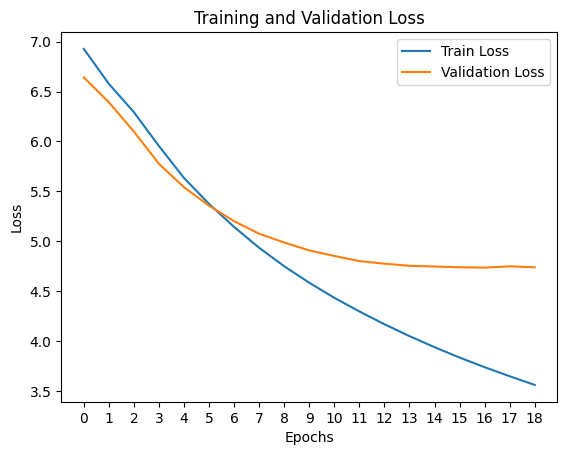

In [164]:
plt.plot(range(len(train_losses)), train_losses, label='Train Loss')
plt.plot(range(len(val_losses)), val_losses, label='Validation Loss')
plt.legend()
plt.xticks(range(len(train_losses)))
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

## 3.3. 인퍼런스 모델 구현

In [179]:
src_index_to_word = {idx: word for word, idx in src_vocab.items()} # 원문(text) 단어 집합에서 정수 -> 단어를 얻음
tar_word_to_index = tar_vocab # 요약(headlines) 단어 집합에서 단어 -> 정수를 얻음
tar_index_to_word = {idx: word for word, idx in tar_vocab.items()} # 요약(headlines) 단어 집합에서 정수 -> 단어를 얻음


In [180]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder.to(device)

Decoder(
  (embedding): Embedding(9500, 128)
  (lstm): LSTM(128, 256, num_layers=3, batch_first=True, dropout=0.4)
)

In [181]:
# 인코더 설계
def encode_input(encoder, input_seq):
    encoder_outputs, hidden, cell = encoder(input_seq)
    return encoder_outputs, hidden, cell

In [182]:
# 이전 시점의 상태들을 저장하는 텐서
num_layers = 3  # 디코더 LSTM 레이어 개수 (설정에 맞춰 조정)
batch_size = 1

decoder_state_input_h = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_state_input_c = torch.zeros((num_layers, batch_size, hidden_size), dtype=torch.float, device=device)
decoder_input = torch.zeros((batch_size, 1), dtype=torch.long, device=device)

dec_emb2 = decoder.embedding(decoder_input)

# 문장의 다음 단어를 예측하기 위해서 초기 상태(initial_state)를 이전 시점의 상태로 사용. 
# 이는 뒤의 함수 decode_sequence()에 구현
# 훈련 과정에서와 달리 LSTM이 반환하는 hidden_state(state_h)와 cell_state(state_c)를 버리지 않음.
decoder_outputs2, state_h2, state_c2 = decoder(decoder_input, decoder_state_input_h, decoder_state_input_c)

In [183]:
class DecoderWithAttention(nn.Module):
    def __init__(self, decoder, attention, hidden_size, vocab_size):
        super(DecoderWithAttention, self).__init__()
        self.decoder = decoder  # 기존 디코더
        self.attention = attention  # 어텐션 레이어
        self.concat = nn.Linear(hidden_size * 2, hidden_size)  # 어텐션 결합 레이어
        self.output_layer = nn.Linear(hidden_size, vocab_size)  # 최종 출력층
        self.softmax = nn.Softmax(dim=-1)  # 소프트맥스

    def forward(self, decoder_inputs, decoder_hidden_state, decoder_state_h, decoder_state_c):
        # 디코더 실행
        decoder_outputs, state_h, state_c = self.decoder(decoder_inputs, decoder_state_h, decoder_state_c)

        # 어텐션 적용
        attn_out = self.attention(decoder_outputs, decoder_hidden_state)

        # 어텐션과 디코더 출력 결합
        decoder_concat_output = torch.cat((decoder_outputs, attn_out), dim=-1)
        decoder_concat_output = torch.tanh(self.concat(decoder_concat_output))

        # 최종 출력층 적용
        decoder_outputs2 = self.softmax(self.output_layer(decoder_concat_output))

        return decoder_outputs2, state_h, state_c

In [184]:
# 기존 Attention 클래스 사용
attention_layer = Attention_dot(hidden_size)

# 디코더 모델 생성
decoder_model = DecoderWithAttention(decoder, attention_layer, hidden_size, tar_vocab_size)

In [185]:
def decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, hline_max_len, device):
    # 입력을 PyTorch Tensor로 변환
    input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)

    # 인코더 실행하여 초기 상태(hidden, cell) 얻기
    with torch.no_grad():
        e_out, e_h, e_c = encoder(input_seq)

    e_out = e_out.repeat(1, text_max_len, 1)  # 차원 조정 (np.tile 대신 repeat 사용)

    # <SOS>에 해당하는 토큰 생성
    target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
    target_seq[0, 0] = tar_word_to_index['bostoken']

    stop_condition = False
    decoded_sentence = ''

    while not stop_condition:
        # 디코더 실행
        with torch.no_grad():
            output_tokens, h, c = decoder(target_seq, e_h, e_c)

        # 가장 높은 확률을 가진 단어 선택
        sampled_token_index = torch.argmax(output_tokens[0, -1, :]).item()
        sampled_token = tar_index_to_word[sampled_token_index]

        if sampled_token != 'eostoken':
            decoded_sentence += ' ' + sampled_token

        # 종료 조건: <eos>에 도달하거나 최대 길이를 초과하면 중단
        if sampled_token == 'eostoken' or len(decoded_sentence.split()) >= (hline_max_len - 1):
            stop_condition = True

        # 길이가 1인 타겟 시퀀스를 업데이트
        target_seq = torch.zeros((1, 1), dtype=torch.long, device=device)
        target_seq[0, 0] = sampled_token_index

        # 상태 업데이트
        e_h, e_c = h, c

    return decoded_sentence

In [186]:
# 원문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2text(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0:  # 패딩(0) 제외
            temp = temp + src_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()

# 요약문의 정수 시퀀스를 텍스트 시퀀스로 변환
def seq2summary(input_seq):
    temp = ''
    for i in input_seq:
        key = int(i.item())  # PyTorch Tensor → int 변환
        if key != 0 and key != tar_word_to_index['bostoken'] and key != tar_word_to_index['eostoken']:
            temp = temp + tar_index_to_word.get(key, "<UNK>") + ' '  # 안전한 조회
    return temp.strip()  # 양쪽 공백 제거

In [187]:
%%time
for i in range(40, 60):
    print("원문 :", seq2text(encoder_input_test[i]))
    print("실제 요약 :", seq2summary(decoder_input_test[i]))
    input_seq = torch.tensor(encoder_input_test[i], dtype=torch.long, device=device).unsqueeze(0)
    print("예측 요약 :", decode_sequence(input_seq, encoder, decoder, tar_word_to_index, tar_index_to_word, text_max_len, hline_max_len, device))
    print("\n")

원문 : ghaziabad police wednesday arrested year old man stabbed pregnant wife want fourth child three daughters man filed missing complaint woman family lodged fir raised suspicion murder meanwhile police trying verify woman pregnant murder august
실제 요약 : man kills pregnant wife over th child files missing complaint
예측 요약 :  win own new its days own show own while while while


원문 : telecom major bharti airtel chinese telecom equipment manufacturer huawei friday announced successfully conducted india first ever trial achieving data speed gb per second comes days state run bsnl signed pact japan <UNK> indian partner <UNK> corps create test bed
실제 요약 : india st trial successful gb per sec speed achieved
예측 요약 :  own rahul new gold own days own gold at at son


원문 : army northern command chief lieutenant general devraj <UNK> wednesday said terrorists pakistan ready enter india talking retaliation <UNK> army camp attack six jawans killed <UNK> said operations along border complex feel really

<timed exec>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
/tmp/ipykernel_1246241/4209954898.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_seq = torch.tensor(input_seq, dtype=torch.long, device=device)


예측 요약 :  win own new win own win own win it not singh


원문 : mukesh ambani led reliance jio planning create cryptocurrency called jiocoin according reports mukesh ambani son akash expected lead project comprising member team young professionals work blockchain technology jiocoin jio also use technology smart contracts supply chain management logistics
실제 요약 : reliance jio planning its own cryptocurrency <UNK>
예측 요약 :  mumbai lakh new its days raises wife raises asks son raises


원문 : actor arjun rampal monday posted picture rumoured girlfriend <UNK> <UNK> instagram captioned wedding mine arjun wife former supermodel mehr <UNK> announced separation years marriage may last year relationships end love lives two issued joint statement announcement
실제 요약 : at wedding not mine arjun on pic with rumoured girlfriend
예측 요약 :  does new house raises wife gandhi gandhi it asks twitter back


원문 : team india captain virat kohli featured highest earning sportsperson forbes india celebrity list crore

# 4. Extractive Summarization

In [198]:
raw_data = pd.read_csv(DATA_PATH + 'news_summary_more.csv', encoding='iso-8859-1')

In [199]:
text = list(raw_data['text'])
summary_text = list(raw_data['headlines'])

In [209]:
start_idx = 40
end_idx = 60

for i in range(start_idx, end_idx):
    text_to_summarize = raw_data['text'][i]
    print(f"원문 {i}: {text_to_summarize}")    
    
    res = summarize(text_to_summarize, ratio=0.5)
    
    print(f"실제 요약: {raw_data['headlines'][i]}")
    print(f"추출 요약: {res if res else '분량 부족으로 추출 실패'}")
    print("-" * 50)

원문 40: Ex-ICICI Bank CEO Chanda Kochhar said she's "utterly disappointed, hurt and shocked" by the bank's decision to terminate her. Kochhar said she served ICICI for 34 years with utmost honesty and integrity and that ultimately truth will prevail. Adding that she hasn't been given a copy of the independent probe report, Kochhar said none of ICICI's credit decisions are unilateral
실제 요약: Shocked, hurt by ICICI's decision, truth will prevail: Kochhar
추출 요약: Adding that she hasn't been given a copy of the independent probe report, Kochhar said none of ICICI's credit decisions are unilateral
--------------------------------------------------
원문 41: Swedish multinational fast-fashion brand Hennes & Mauritz AB (H&M) has hired Christopher Wylie, the whistleblower who exposed Facebook's Cambridge Analytica data scandal. WylieÃ¢ÂÂs focus will be to help get better insights on customers, products and markets and support work on sustainable and ethical artificial intelligence, H&M spokesperso

# 5. 결과 비교

### 요약 모델 성능 비교 분석

| 평가 항목 | 추상적 요약 (Abstractive) | 추출 요약 (Extractive) |
| :--- | :--- | :--- |
| **핵심 기법** | Seq2Seq + Attention (LSTM) | TextRank (Summa 라이브러리) |
| **문법 완성도** | **상대적으로 낮음**| **상대적으로 높음** |
| **핵심 단어 포함** | **상대적으로 못함** | **상대적으로 잘함**|


---

### 결과 정리
1. **추상적 요약**  
모델이 문맥을 이해하여 새로운 요약문을 생성하는 시도는 바람직함. 그러나 현재 결과에서는 '반복 생성 문제(Repetition Problem)'가 발생하여 의미 없는 단어가 반복됨(`while`,
 `does`).  
 추후 loss를 더 낮추기 위해 알고리즘 개선이나 하이퍼파라미터 튜닝으로 보완해야겠다.

2. **추출 요약**  
짧은 뉴스 기사 데이터셋에서는 문장 간 가중치를 계산할 근거가 부족하여 결과물이 생략되는 경우가 많아서, 긴 기사 원문이나 다중 문장 데이터에 더 적합한 모델임을 확인함.  
원문의 문장을 그대로 발췌하므로 문법적으로 부자연스러울 수 있으나, 학습이 부족한 seq2seq보다는 자연스러워 보임.

# 회고

- 생각보다 전처리에 많은 비중을 할애해야 한다는 것을 실감함
- 단일 RNN 모델만 사용하다가 인코더-디코더 구조에 어텐션까지 결합하려니 복잡해서, 좀더 숙지해야겠다고 생각했음
- pandas에서 unique한 샘플 수 계산할 때, 사용하는 함수에 따라 계산 방식이 다른 것을 알게 되었음  
    - unique(): NaN을 포함하여 유일한 값을 찾을 찾음  
    - nunique(): 기본적으로 NaN을 제외하고 계수  